<a href="https://colab.research.google.com/github/Roxiskil/Python/blob/main/week_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
  City_Name River_Name  Pollution_Level  Measurement_Year Contaminant_Index
0    Dundee        Tay               12              2010                 5
1     Perth        Tay               15              2010                 8
2   Newport        Tay               18              2010                13
3     Cupar      Leven               21              2010                21
4   Kinross      Leven               25              2010                34

Average pollution per river:
Tay: 35.777778
Leven: 34.350000
St_Andrews_Burn: 35.400000
Ericht: 36.800000

Most polluted river: Ericht
Average pollution level: 36.80


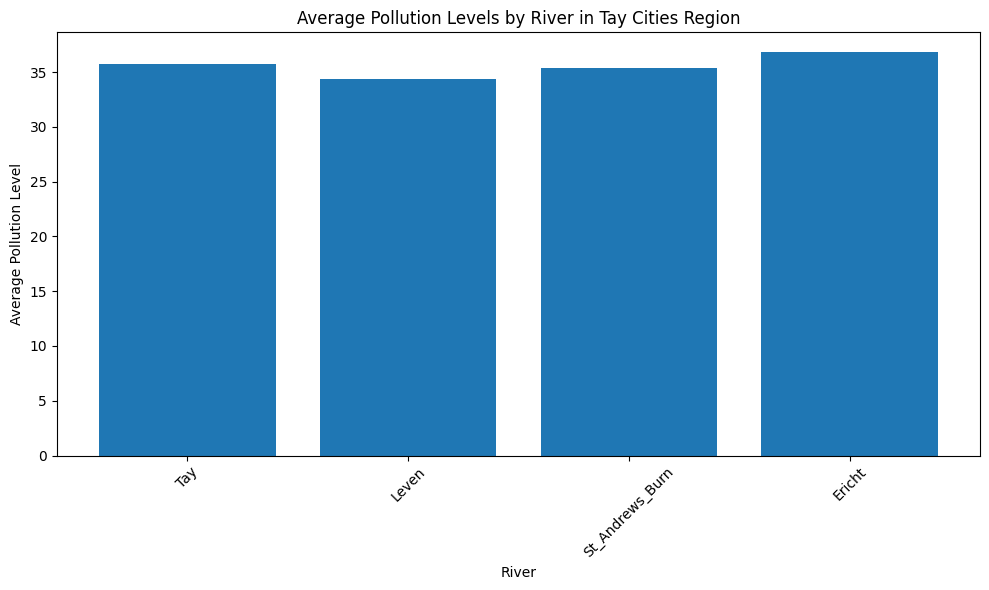

Saved as average_pollution_by_river.csv


In [ ]:
# Practice 1: Recursively calculate average pollution per river and identify the most polluted river
import pandas as pd
import matplotlib.pyplot as plt

#Load csv
data = pd.read_csv("TaySewage.csv")

# Show first rows
print("First 5 rows:")
print(data.head())

#Clean data
data = data.dropna()

#Pollution column should be numeric
data["Pollution_Level"] = pd.to_numeric(data["Pollution_Level"], errors="coerce")

#Drop rows where pollution could not be converted
data = data.dropna(subset=["Pollution_Level"])

#Conver dataframe to list of dictionaries
records = data.to_dict(orient="records")

#Recursive function to calculate average pollution for one river
def avg_pollution_river(records, river_name, index=0, total=0, count=0):
  if index == len(records):
    return total / count if count != 0 else 0
  rec = records[index]

  if rec["River_Name"] == river_name:
    total += rec["Pollution_Level"]
    count += 1

  return avg_pollution_river(records, river_name, index + 1, total, count)

#Get unique rivers
rivers = data["River_Name"].unique()

#Calculate averages recursively
river_avg_pollution = {}
for river in rivers:
  river_avg_pollution[river] = avg_pollution_river(records, river)

#Print results
print("\nAverage pollution per river:")
for river, avg in river_avg_pollution.items():
  print(f"{river}: {avg:2f}")

#Find the most polluted river
most_polluted_river = max(river_avg_pollution, key=river_avg_pollution.get)
print(f"\nMost polluted river: {most_polluted_river}")
print(f"Average pollution level: {river_avg_pollution[most_polluted_river]:.2f}")

#Bar chart
plt.figure(figsize=(10,6))
plt.bar(river_avg_pollution.keys(), river_avg_pollution.values())
plt.xlabel("River")
plt.ylabel("Average Pollution Level")
plt.title("Average Pollution Levels by River in Tay Cities Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Save csv file
result_df = pd.DataFrame(list(river_avg_pollution.items()), columns=["River_Name", "Average_Pollution"])
result_df.to_csv("average_pollution_by_river.csv", index=False)
print("Saved as average_pollution_by_river.csv")

First 5 rows with prediction:
  City_Name  Measurement_Year  Pollution_Level  Predicted_Contaminant
0    Dundee              2010               12                     67
1     Perth              2010               15                     70
2   Newport              2010               18                     73
3     Cupar              2010               21                     76
4   Kinross              2010               25                     80


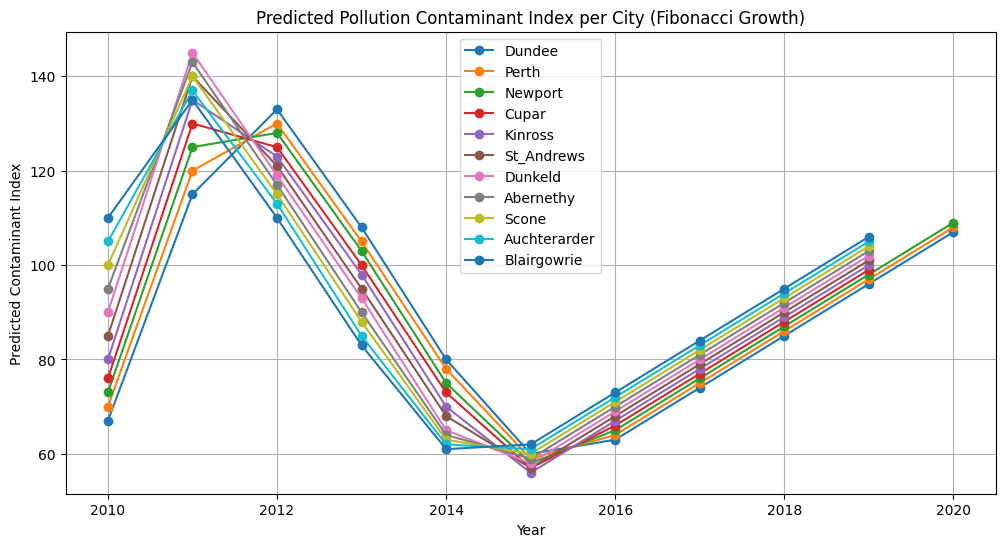

Saved as future_contamination_predictions.csv


In [ ]:
#Use Fibonacci sequence to predict future contaminant indices, then visualise trends
import pandas as pd
import matplotlib.pyplot as plt

#Load csv
data = pd.read_csv("TaySewage.csv")

#Clean data
data = data.dropna()

# Convert important columns to correct types
data["Pollution_Level"] = pd.to_numeric(data["Pollution_Level"], errors="coerce")
data["Measurement_Year"] = pd.to_numeric(data["Measurement_Year"], errors="coerce")

# Remove rows with missing numeric values
data = data.dropna(subset=["Pollution_Level", "Measurement_Year"])

# Make year integer
data["Measurement_Year"] = data["Measurement_Year"].astype(int)

# Fibonacci function with memoization
def fibonacci(n, memo={}):
    if n <= 1:
        return n
    if n in memo:
        return memo[n]
    memo[n] = fibonacci(n - 1, memo) + fibonacci(n - 2, memo)
    return memo[n]

# Use a Fibonacci number as a simple growth factor
fib_value = fibonacci(10)

# Create predicted contaminant index
data["Predicted_Contaminant"] = data["Pollution_Level"] + fib_value

# Show first rows
print("First 5 rows with prediction:")
print(data[["City_Name", "Measurement_Year", "Pollution_Level", "Predicted_Contaminant"]].head())

# Plot line chart for each city
plt.figure(figsize=(12, 6))

for city in data["City_Name"].unique():
    city_data = data[data["City_Name"] == city].sort_values("Measurement_Year")
    plt.plot(city_data["Measurement_Year"], city_data["Predicted_Contaminant"], marker='o', label=city)

plt.xlabel("Year")
plt.ylabel("Predicted Contaminant Index")
plt.title("Predicted Pollution Contaminant Index per City (Fibonacci Growth)")
plt.legend()
plt.grid(True)
plt.show()

#Save csv file
data.to_csv("future_contamination_predictions.csv", index=False)
print("Saved as future_contamination_predictions.csv")



In [ ]:
#Recursively find the most popular beach in a list simulating hierarchical data explolation

import pandas as pd

# Load CSV
data = pd.read_csv("FifeCoastal.csv")   # change name if needed

# Clean data
data = data.dropna()

# Make sure popularity score is numeric
data["Popularity_Score"] = pd.to_numeric(data["Popularity_Score"], errors="coerce")
data = data.dropna(subset=["Popularity_Score"])

# Convert to list of dictionaries
beaches = data.to_dict(orient="records")

# Recursive function to find most popular beach
def most_popular(beach_list, index=0, current_best=None):
    if index == len(beach_list):
        return current_best

    beach = beach_list[index]

    if current_best is None or beach["Popularity_Score"] > current_best["Popularity_Score"]:
        current_best = beach

    return most_popular(beach_list, index + 1, current_best)

# Find result
best_beach = most_popular(beaches)

print("Most Popular Beach in Fife Coastal Region:")
print(f"{best_beach['Beach_Name']} with Popularity Score {best_beach['Popularity_Score']}")

import matplotlib.pyplot as plt

# Sort beaches by popularity
import matplotlib.pyplot as plt


Most Popular Beach in Fife Coastal Region:
StMonans with Popularity Score 92.0


In [ ]:
#Estimate visitor growth for beaches using Fibonacci sequence (predictive modelling). Assume popularity influences growth and visito counts roughly follow Fibonacci ratios

import pandas as pd

# Load CSV
data = pd.read_csv("FifeCoastal.csv")

# Clean data
data = data.dropna()
data["Visitor_Count"] = pd.to_numeric(data["Visitor_Count"], errors="coerce")
data = data.dropna(subset=["Visitor_Count"])
data = data.reset_index(drop=True)

# Fibonacci function
def fibonacci(n, memo={}):
    if n <= 1:
        return n
    if n in memo:
        return memo[n]
    memo[n] = fibonacci(n - 1, memo) + fibonacci(n - 2, memo)
    return memo[n]

results = []

for i, row in data.head(10).iterrows():
    fib_value = fibonacci(i + 5)
    predicted_visitors = int(row["Visitor_Count"]) + fib_value * 100
    results.append({
        "Beach_Name": row["Beach_Name"],
        "Current_Visitors": int(row["Visitor_Count"]),
        "Predicted_Visitors": predicted_visitors
    })

result_df = pd.DataFrame(results)
print(result_df)

       Beach_Name  Current_Visitors  Predicted_Visitors
0            Elie                 5                 505
1  St_Andrews_Bay                 8                 808
2      Kingsbarns                13                1313
3     West_Wemyss                21                2121
4    Dysart_Beach                34                3434
5         Culross                55                5555
6     Burntisland                89                8989
7        Seafield               144               14544
8      Pittenweem               233               23533
9      Anstruther               377               38077


/tmp/ipykernel_611/519592693.py:17: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(Rectangle((x - 0.05, y - 0.05), 0.1, 0.1,


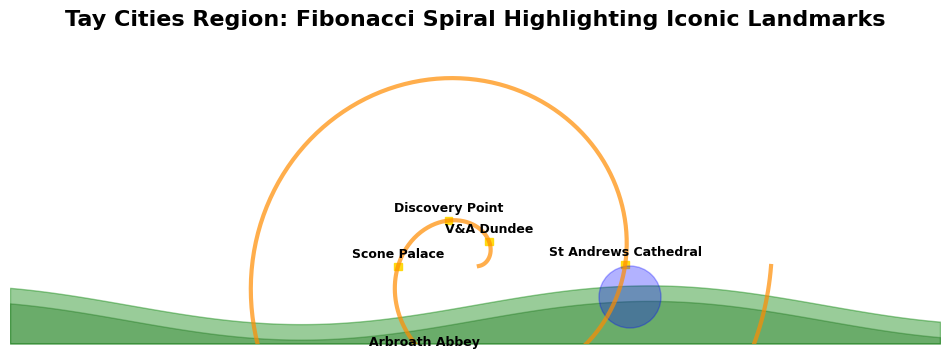

<Figure size 640x480 with 0 Axes>

In [ ]:
# Additional task
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Circle

#Functions
def fibonacci_spiral(a, b, n_points=500):
    """Generate points for a prominent Fibonacci spiral."""
    theta = np.linspace(0, 4 * np.pi, n_points)
    r = a + b * theta
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y

def draw_landmark(ax, x, y, name, color='gold'):
    """Draw a landmark as a small building icon."""
    ax.add_patch(Rectangle((x - 0.05, y - 0.05), 0.1, 0.1,
                           color=color, alpha=0.9, edgecolor='black'))
    ax.text(x, y + 0.08, name, fontsize=9, ha='center', va='bottom', fontweight='bold')

# Visualization
fig, ax = plt.subplots(figsize=(12, 10))

# Minimalist hills in background
x = np.linspace(-6, 6, 600)
y_hills = 0.25 * np.sin(x * 0.7) - 0.5
ax.fill_between(x, y_hills, -1, color='green', alpha=0.4)
ax.fill_between(x, y_hills - 0.2, -1, color='darkgreen', alpha=0.3)

# Prominent Fibonacci spiral
x_s, y_s = fibonacci_spiral(a=0.05, b=0.3, n_points=600)
ax.plot(x_s, y_s, color='darkorange', lw=3, alpha=0.7, label='Fibonacci Spiral')

# Tay Cities Region landmarks
landmarks = [
    {'name': 'V&A Dundee', 'pos': (x_s[50], y_s[50])},
    {'name': 'Discovery Point', 'pos': (x_s[100], y_s[100])},
    {'name': 'Scone Palace', 'pos': (x_s[150], y_s[150])},
    {'name': 'Arbroath Abbey', 'pos': (x_s[200], y_s[200])},
    {'name': 'St Andrews Cathedral', 'pos': (x_s[300], y_s[300])}
]

for lm in landmarks:
    draw_landmark(ax, lm['pos'][0], lm['pos'][1], lm['name'])

# Tay Loch / estuary as water element
loch = Circle((2.0, -0.4), 0.4, color='blue', alpha=0.3)
ax.add_artist(loch)

# Aesthetic tweaks
ax.set_xlim(-6, 6)
ax.set_ylim(-1, 3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Tay Cities Region: Fibonacci Spiral Highlighting Iconic Landmarks",
             fontsize=16, fontweight='bold')

plt.show()

plt.savefig("tay_fibonacci_spiral.png", dpi=300, bbox_inches="tight")